<a href="https://colab.research.google.com/github/TomHacker69/MSE_CA1/blob/main/CASE_STUDY_2_Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("siddharth0935/hospital-readmission-predictionsynthetic-dataset")

Using Colab cache for faster access to the 'hospital-readmission-predictionsynthetic-dataset' dataset.


In [ ]:
import os

print("Dataset path:")
print(path)

print("\nFiles inside dataset:")
print(os.listdir(path))

Dataset path:
/kaggle/input/hospital-readmission-predictionsynthetic-dataset

Files inside dataset:
['hospital_readmissions_30k.csv', 'readmissions_metadata.json']


In [ ]:
import pandas as pd
import os

file_path = os.path.join(
    path,
    "hospital_readmissions_30k.csv"
)

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (30000, 12)


,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

Columns:
['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']

Data Types:
patient_id                 int64
age                        int64
gender                    object
blood_pressure            object
cholesterol                int64
bmi                      float64
diabetes                  object
hypertension              object
medication_count           int64
length_of_stay             int64
discharge_destination     object
readmitted_30_days        object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 

In [ ]:
metadata_path = os.path.join(
    path,
    "readmissions_metadata.json"
)

with open(metadata_path, "r") as f:
    metadata = f.read()

print(metadata)

{
    "description": "Synthetic dataset mimicking real-world hospital readmissions patterns.",
    "size": "30,000 records",
    "source": "Generated synthetically with risk-based rules",
    "use_cases": [
        "Predictive modeling",
        "Healthcare analytics"
    ],
    "columns": [
        "patient_id",
        "age",
        "gender",
        "blood_pressure",
        "cholesterol",
        "bmi",
        "diabetes",
        "hypertension",
        "medication_count",
        "length_of_stay",
        "discharge_destination",
        "readmitted_30_days"
    ]
}


In [ ]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (30000, 12)

Missing Values:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64

Duplicate Rows: 0


In [ ]:
print("Readmission Distribution:")
print(df["readmitted_30_days"].value_counts())

print("\nReadmission Percentage:")
print(df["readmitted_30_days"].value_counts(normalize=True) * 100)

Readmission Distribution:
readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64

Readmission Percentage:
readmitted_30_days
No     87.753333
Yes    12.246667
Name: proportion, dtype: float64


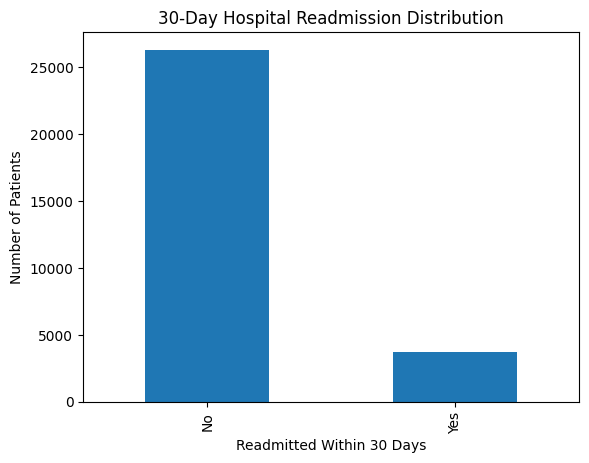

In [ ]:
import matplotlib.pyplot as plt

df["readmitted_30_days"].value_counts().plot(kind="bar")

plt.title("30-Day Hospital Readmission Distribution")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Number of Patients")
plt.show()

In [ ]:
X = df.drop(
    columns=["patient_id", "readmitted_30_days"]
)

y = df["readmitted_30_days"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (30000, 10)
Target: (30000,)


In [ ]:
print("Numerical Features:")
print(
    X.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()
)

print("\nCategorical Features:")
print(
    X.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()
)

Numerical Features:
['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']

Categorical Features:
['gender', 'blood_pressure', 'diabetes', 'hypertension', 'discharge_destination']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training Features: (24000, 10)
Testing Features: (6000, 10)

Training Target Distribution:
readmitted_30_days
No     21061
Yes     2939
Name: count, dtype: int64

Testing Target Distribution:
readmitted_30_days
No     5265
Yes     735
Name: count, dtype: int64


In [ ]:
numeric_features = [
    "age",
    "blood_pressure",
    "cholesterol",
    "bmi",
    "medication_count",
    "length_of_stay"
]

categorical_features = [
    "gender",
    "diabetes",
    "hypertension",
    "discharge_destination"
]

In [ ]:
print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['age', 'blood_pressure', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay']
Categorical: ['gender', 'diabetes', 'hypertension', 'discharge_destination']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                solver="liblinear",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [ ]:
# Make a copy
df_processed = df.copy()

# Split blood pressure into systolic and diastolic
df_processed[["systolic_bp", "diastolic_bp"]] = (
    df_processed["blood_pressure"]
    .str.split("/", expand=True)
    .astype(float)
)

# Remove original blood_pressure column
df_processed = df_processed.drop(columns=["blood_pressure"])

print(df_processed.head())
print("\nNew columns:")
print(df_processed.columns.tolist())

   patient_id  age  gender  cholesterol   bmi diabetes hypertension  \
0           1   74   Other          240  31.5      Yes           No   
1           2   46  Female          292  36.3       No           No   
2           3   89   Other          153  30.3       No          Yes   
3           4   84  Female          153  31.5       No          Yes   
4           5   32   Other          205  18.4       No          Yes   

   medication_count  length_of_stay discharge_destination readmitted_30_days  \
0                 5               1      Nursing_Facility                Yes   
1                 4               3      Nursing_Facility                 No   
2                 1               1                  Home                 No   
3                 3              10                  Home                 No   
4                 6               4      Nursing_Facility                 No   

   systolic_bp  diastolic_bp  
0        130.0          72.0  
1        120.0          92.0  

In [ ]:
print(df_processed[["systolic_bp", "diastolic_bp"]].head())

print("\nData types:")
print(
    df_processed[
        ["systolic_bp", "diastolic_bp"]
    ].dtypes
)

   systolic_bp  diastolic_bp
0        130.0          72.0
1        120.0          92.0
2        135.0          78.0
3        123.0          80.0
4        135.0          84.0

Data types:
systolic_bp     float64
diastolic_bp    float64
dtype: object


In [ ]:
X = df_processed.drop(
    columns=["patient_id", "readmitted_30_days"]
)

y = df_processed["readmitted_30_days"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 11)
y shape: (30000,)


In [ ]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay', 'systolic_bp', 'diastolic_bp']

Categorical Features:
['gender', 'diabetes', 'hypertension', 'discharge_destination']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (24000, 11)
Testing: (6000, 11)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                solver="liblinear",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [ ]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("First 10 probabilities:")
print(y_prob[:10])

Predictions generated successfully!
First 10 probabilities:
[0.11139239 0.1580189  0.097695   0.15717733 0.12137463 0.15338624
 0.09966523 0.16772353 0.0768707  0.10631532]


In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.5638


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Readmission",
            "Readmitted"
        ]
    )
)

                precision    recall  f1-score   support

No Readmission       0.88      1.00      0.93      5265
    Readmitted       0.00      0.00      0.00       735

      accuracy                           0.88      6000
     macro avg       0.44      0.50      0.47      6000
  weighted avg       0.77      0.88      0.82      6000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives  (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives  (TP):", tp)

True Negatives  (TN): 5265
False Positives (FP): 0
False Negatives (FN): 735
True Positives  (TP): 0


In [ ]:
y = df_processed["readmitted_30_days"].map({
    "No": 0,
    "Yes": 1
})

print(y.value_counts())
print(y.unique())

readmitted_30_days
0    26326
1     3674
Name: count, dtype: int64
[1 0]


In [ ]:
X = df_processed.drop(
    columns=["patient_id", "readmitted_30_days"]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (24000, 11)
Testing: (6000, 11)


In [ ]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
print("Actual labels:", y_test.unique())
print("Predicted labels:", set(y_pred))

Actual labels: [0 1]
Predicted labels: {np.int64(0)}


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== Model Performance =====")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

===== Model Performance =====
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.5638


In [ ]:
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===== Logistic Regression Performance =====")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\n===== Classification Report =====")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Readmission", "Readmitted"]
    )
)

===== Logistic Regression Performance =====
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000
ROC-AUC   : 0.5638

===== Classification Report =====
                precision    recall  f1-score   support

No Readmission       0.88      1.00      0.93      5265
    Readmitted       0.00      0.00      0.00       735

      accuracy                           0.88      6000
     macro avg       0.44      0.50      0.47      6000
  weighted avg       0.77      0.88      0.82      6000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

Confusion Matrix:
[[5265    0]
 [ 735    0]]

True Negative  (TN): 5265
False Positive (FP): 0
False Negative (FN): 735
True Positive  (TP): 0


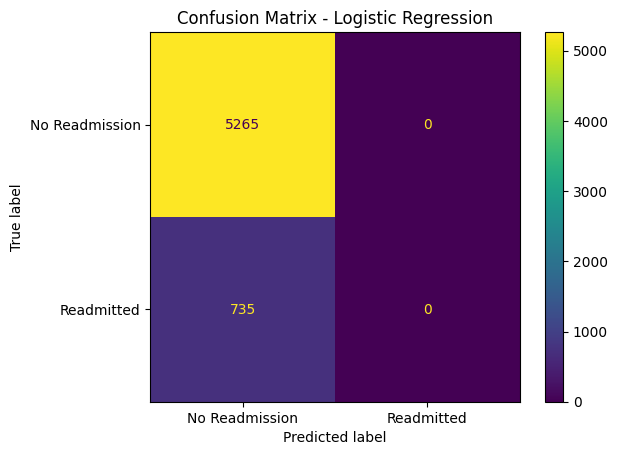

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negative  (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive  (TP):", tp)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Readmission", "Readmitted"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

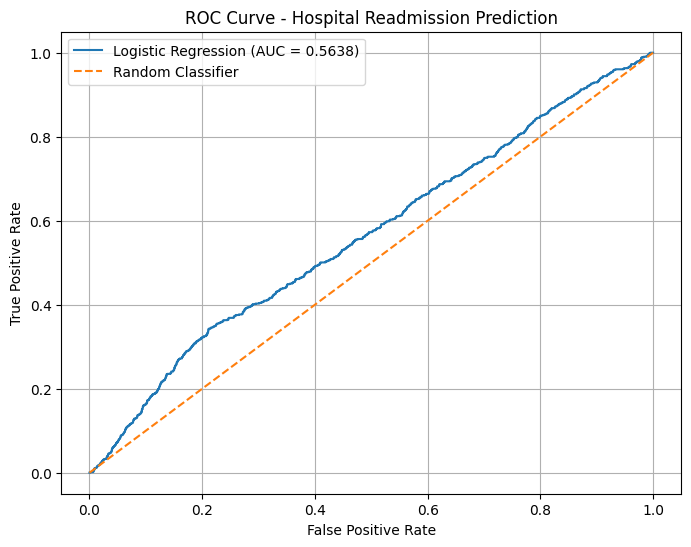

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()
plt.grid()

plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Get transformed feature names
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get logistic regression coefficients
coefficients = model.named_steps["classifier"].coef_[0]

# Create dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
})

# Sort by absolute coefficient
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

print("Top features affecting readmission:")
display(coef_df.head(15))

Top features affecting readmission:


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
14,cat__discharge_destination_Home,-0.654121,0.519899,0.654121
10,cat__diabetes_No,-0.415728,0.659859,0.415728
12,cat__hypertension_No,-0.409899,0.663717,0.409899
13,cat__hypertension_Yes,-0.257412,0.773050,0.257412
11,cat__diabetes_Yes,-0.251583,0.777569,0.251583
8,cat__gender_Male,-0.234381,0.791060,0.234381
7,cat__gender_Female,-0.227208,0.796755,0.227208
9,cat__gender_Other,-0.205722,0.814059,0.205722
2,num__bmi,-0.042179,0.958698,0.042179
15,cat__discharge_destination_Nursing_Facility,-0.040029,0.960761,0.040029


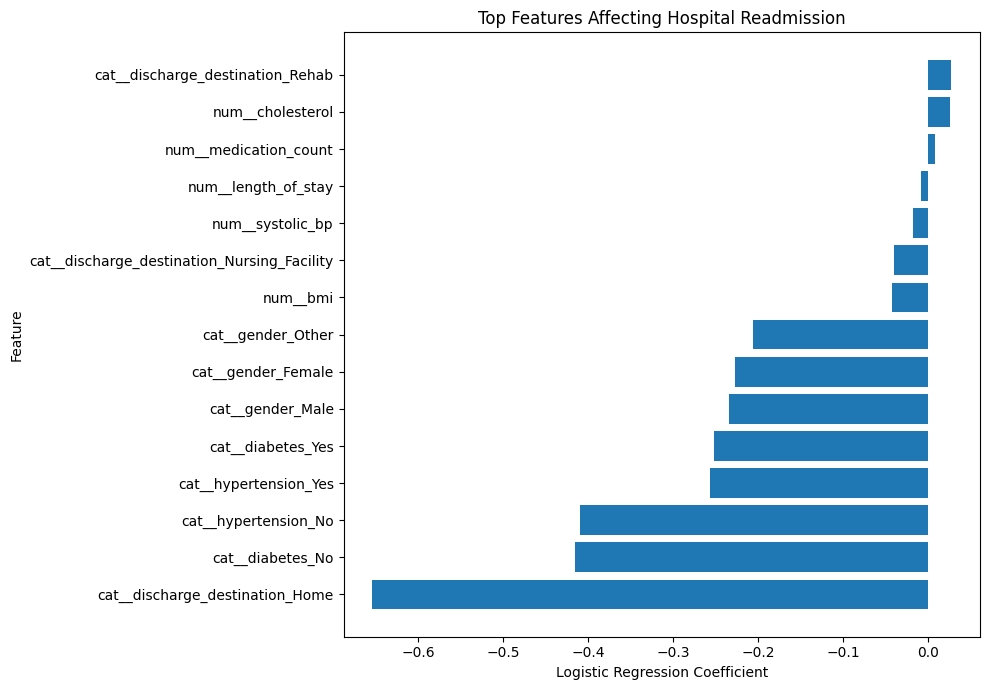

In [ ]:
top_features = coef_df.head(15).sort_values("Coefficient")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Affecting Hospital Readmission")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("Threshold Analysis\n")

for threshold in thresholds:

    y_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_threshold)
    recall = recall_score(y_test, y_threshold)
    f1 = f1_score(y_test, y_threshold)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold Analysis

Threshold: 0.3 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Threshold: 0.4 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Threshold: 0.5 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Threshold: 0.6 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000
Threshold: 0.7 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.p